# Where the Water Flows -- Glacier de Bonne Pierre

In [266]:
using Pkg; Pkg.activate("/scratch-1/cogier/hydraulic_barriers/")
Pkg.resolve()
using Rasters
using Shapefile
using WhereTheWaterFlowsSubglacially, WhereTheWaterFlows
const WWFS = WhereTheWaterFlowsSubglacially
const WWF = WhereTheWaterFlows
using ArchGDAL
#using MAT
using Plots
using GlacioTools
include("/scratch-3/cogier/GlacioTools.jl/src/Rasters_helpers.jl")
#using GLMakie
#Pkg.status()



  Activating project at `/scratch-1/cogier/hydraulic_barriers`
  No Changes to `/scratch-1/cogier/hydraulic_barriers/Project.toml`
  No Changes to `/scratch-1/cogier/hydraulic_barriers/Manifest.toml`


assert_Point

In [3]:
datadir = "/scratch-3/cogier/data/DEM"
#include("helper_functions.jl")

"/scratch-3/cogier/data/DEM"

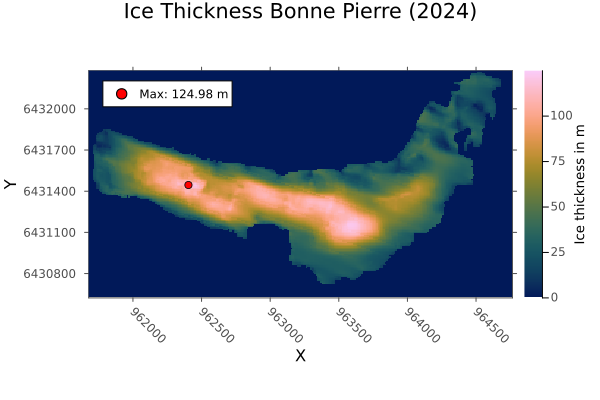

In [252]:
# Bonne Pierreice thickness 2024
ice_thickness = Raster(joinpath(datadir,"IceThickness_BP_2024.tif"));
ice_thickness[ice_thickness .< 0] .= 0

# Find max value and its index
max_value = maximum(ice_thickness)
max_index = argmax(ice_thickness)  # Returns linear index
x,y = dims(ice_thickness)
x_max, y_max = x[max_index[1]],y[max_index[2]]

Plots.heatmap(ice_thickness,title="Ice Thickness Bonne Pierre (2024)",colorbar_title="Ice thickness in m") 
scatter!([x_max],[y_max], color=:red, markersize=4,label="Max: $(round(max_value, digits=2)) m")

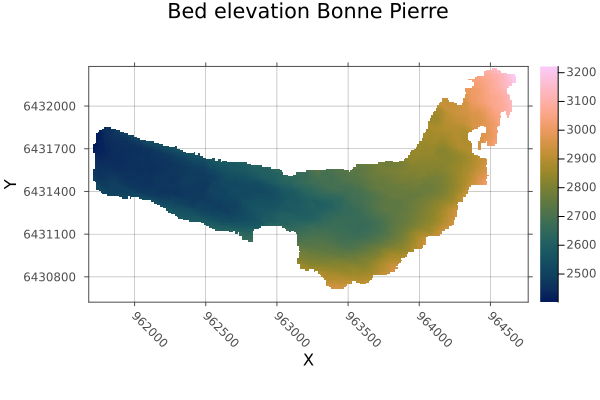

In [133]:
# Bonne Pierre bed
bed = Raster(joinpath(datadir,"Bedrock_BP_2024.tif"));
mask = (bed.> 0)
#bed[bed .< 0] .= NaN # -9999 values
Plots.heatmap(bed,title="Bed elevation Bonne Pierre")
#Plots.contour!(mask, color=:black,levels=[0.5])  




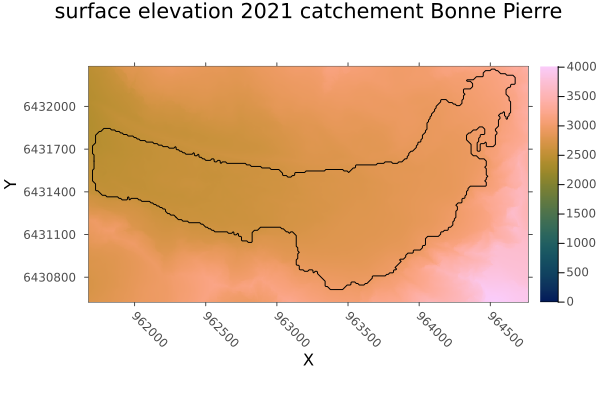

In [130]:
# surface_2021 
all_surf_2021 = Raster(joinpath(datadir,"Berarde_Res1.0_CompElevmean_merged.tif"));
surface_2021 = crop(all_surf_2021; to=ice_thickness)
surface_2021_resamp = resample(surface_2021; to=ice_thickness)
Plots.heatmap(surface_2021,title="surface elevation 2021 catchement Bonne Pierre")
contour!(mask, color=:black,levels=[0.5],title="surface elevation 2021 catchement Bonne Pierre")  

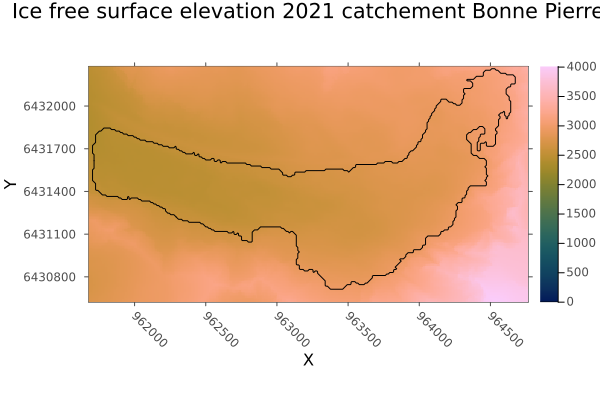

In [132]:
# Glacier free landscape
ice_free_surface_2021 = mosaic(first,bed,surface_2021_resamp)
Plots.heatmap(ice_free_surface_2021,title="Ice free surface elevation 2021 catchement Bonne Pierre")
contour!(mask, color=:black,levels=[0.5],title="Ice free surface elevation 2021 catchement Bonne Pierre")  


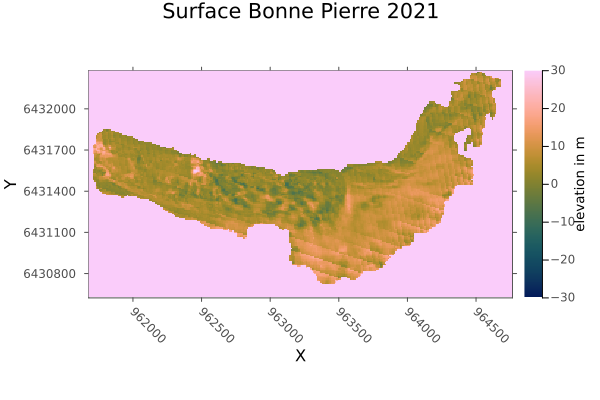

In [ ]:
# difference in elevation surface

# Surface DEM 2024 = IceThickness 2024 + Bedrock
surface_nov_2024 = bed + ice_thickness;
Plots.heatmap(surface_2021_resamp - surface_nov_2024, title="Surface Bonne Pierre 2021", 
colorbar_title="elevation in m",clims=(-30,30))

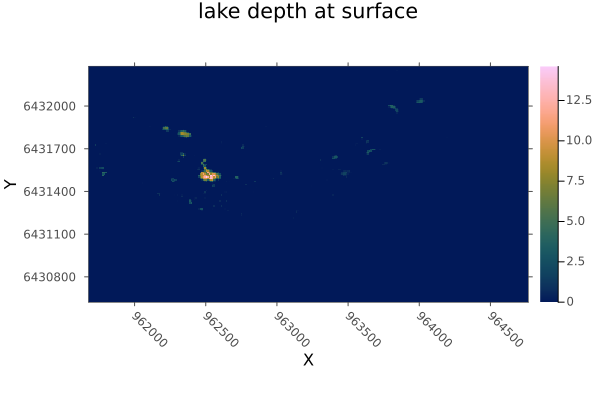

In [281]:
area, slen, dir, nout, nin, sinks, pits, c, bnds = WWF.waterflows(surface_2021_resamp);
#plt_area(area, pits)
demf = fill_dem(surface_2021_resamp, sinks, dir)
# "lake-depth"
x,y = dims(surface_2021_resamp)
lake_surface = demf.-surface_2021_resamp
heatmap(lake_surface,title="lake depth at surface")

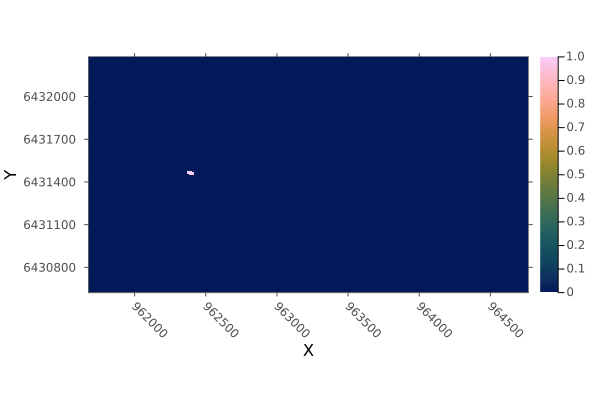

In [212]:
# A single catchment of some point.  Choose one with large catchment:
i, j = max_index[1],max_index[2]
cc = catchment(dir, CartesianIndex(i,j))
heatmap(cc)
#scatter!(x[i], y[j], markersize=50)

In [214]:
## get cell size for WWFS
typeof(bed[:,:,1])
x,y = dims(bed)
dx = x[2] - x[1]

10.683080482995138

In [268]:

# Gamma is the Rothlisberger constant. [1] is without gamma, [2] is gamma=WWFS.GAMMA = -0.31 (Rothlisberger constant = stream deflection)

#surface 2021
(area_2021, slen_2021, dir, nout, nin, pits, c, bnds),
         (sc_locs, kappas, diro, phi_2021),
         (lakes, lakes_free_surf_2021),
         sinkout = WWFS.waterflows_subglacial(surface_2021_resamp, ice_free_surface_2021, dx, gamma=[0,WWFS.GAMMA][1], bnd_as_sink=true, drain_pits=true);

#surface 2024
(area_2024, slen_2024, dir, nout, nin, pits, c, bnds),
(sc_locs, kappas, diro, phi_2024),
(lakes, lakes_free_surf_2024),
sinkout = WWFS.waterflows_subglacial(ice_free_surface_2021 + ice_thickness, ice_free_surface_2021, dx, gamma=[0,WWFS.GAMMA][1], bnd_as_sink=true, drain_pits=true);

#area -- upslope area, tuple containing: total flux (m3/s), extra flux (m3/s), dissipation-melt-rate (m/s), pressure-melt-rate (m/s)



         

((area = ([114.12820860615162 114.12820860615162 … 114.12820860615162 114.12820860615162; 114.12820860615162 114.1686215188219 … 114.17482829973164 114.12820860615162; … ; 114.12820860615162 114.1854119510981 … 114.14474663698603 114.12820860615162; 114.12820860615162 114.12820860615162 … 114.12820860615162 114.12820860615162], Float32[0.0 0.0 … 0.0 0.0; 0.0 0.040412914 … 0.046619695 0.0; … ; 0.0 0.057203345 … 0.016538031 0.0; 0.0 0.0 … 0.0 0.0], Float32[-0.0 -0.0 … -0.0 -0.0; -0.0 0.000354101 … 0.00040848527 -0.0; … ; -0.0 0.00050122006 … 0.00014490748 -0.0; -0.0 -0.0 … -0.0 -0.0], Float32[-0.0 -0.0 … -0.0 -0.0; -0.0 -0.0 … -0.0 -0.0; … ; -0.0 -0.0 … -0.0 -0.0; -0.0 -0.0 … -0.0 -0.0]), slen = [1 1 … 1 1; 1 1 … 1 1; … ; 1 1 … 1 1; 1 1 … 1 1], dir = Int8[10 10 … 10 10; 10 7 … 1 10; … ; 10 8 … 3 10; 10 10 … 10 10], nout = Bool[0 0 … 0 0; 0 1 … 1 0; … ; 0 1 … 1 0; 0 0 … 0 0], nin = Int8[0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0], sinks = CartesianIndex{2}[CartesianIndex(1, 1), Cartes

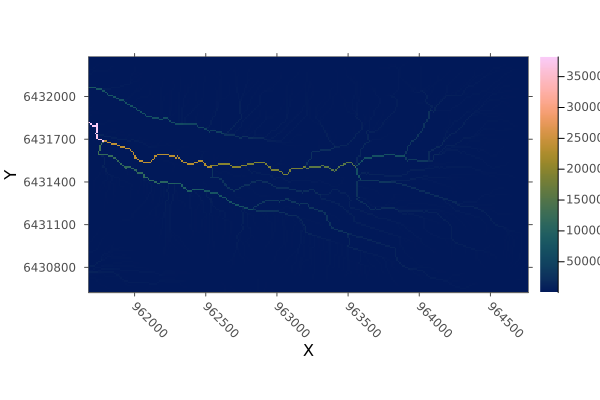

In [254]:
heatmap(area_2024[1])





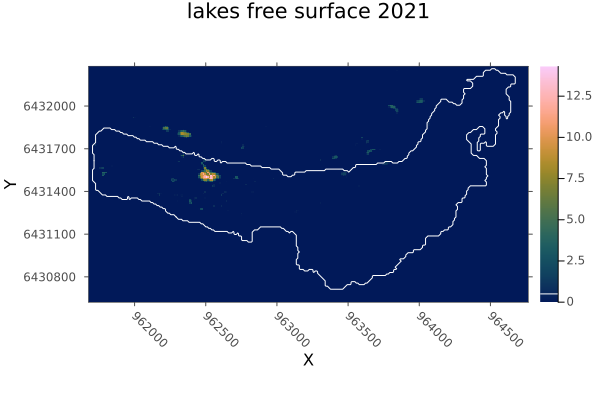

In [256]:
Plots.heatmap(lakes_free_surf_2021,title="lakes free surface 2021")
contour!(mask, color=:white,levels=[0.5],
title="lakes free surface 2021")  

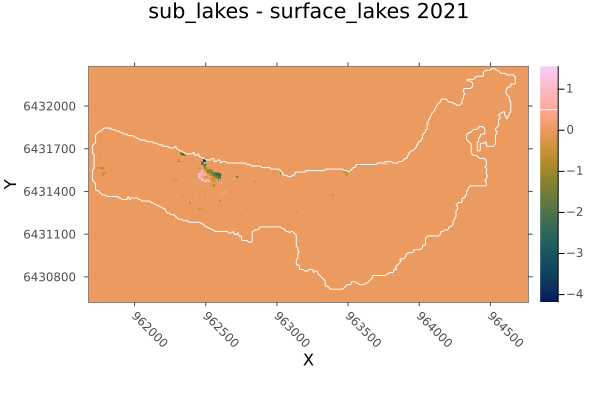

In [284]:
Plots.heatmap(lakes_free_surf_2021 - lake_surface)
contour!(mask, color=:white,levels=[0.5],
title="sub_lakes - surface_lakes 2021")  

In [294]:
# volume for all hydraulic barrier
sum(lakes_free_surf_2021)*dx*dx


125703.45908845389

## Write outputs .TIF ##

In [257]:
#WRITE
write(joinpath(datadir,"lakes_free_surf_2021_BP.tif"),lakes_free_surf_2021,force=true);
write(joinpath(datadir,"phi_2021_BP.tif"),phi_2021,force=true);
write(joinpath(datadir,"lakes_free_surf_2024_BP.tif"),lakes_free_surf_2024,force=true);
write(joinpath(datadir,"phi_2024_BP.tif"),phi_2024,force=true);
write(joinpath(datadir,"area_2024_BP.tif"),area_2024[1],force=true);  
write(joinpath(datadir,"area_2021_BP.tif"),area_2021[1],force=true);
